# Simplified HRM (Hierarchical Reasoning Model) for a Toy RTS-like RL Task

This notebook reproduces a simplified version of the HRM architecture and applies it to a synthetic RL task that imitates key characteristics of RTS micro-management: spatial navigation, resource collection, and build/attack phases.

- Target paper: [HRM (Hierarchical Reasoning Model)](https://arxiv.org/pdf/2506.21734)
- Goal: focus on research fidelity over infrastructure. No online gameplay.

Outline:
1. Problem setup: Toy RTS-like gridworld
2. HRM architecture: Manager (high-level intentions) + Worker (low-level skills)
3. PPO training setup for hierarchical policies
4. Training and analysis
5. Evaluation and ablations


In [ ]:
#%pip install numpy
#%pip install torch
#%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Imports and basic setup
import os
import math
import random
from dataclasses import dataclass
from typing import Tuple, List, Dict, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

@dataclass
class Config:
    grid_size: int = 10
    num_resources: int = 5
    episode_length: int = 1024
    max_inventory: int = 5
    base_build_cost: int = 3
    enemy_spawn_step: int = 60
    num_enemies: int = 2

    manager_intent_horizon: int = 8  # steps an intent is held
    manager_hidden: int = 128
    worker_hidden: int = 128
    intent_dim: int = 4  # {gather, build, scout, attack}

    learning_rate: float = 3e-4
    gamma: float = 0.99
    gae_lambda: float = 0.95
    clip_range: float = 0.2
    ppo_epochs: int = 4
    batch_size: int = 4096

cfg = Config()


## Environment: Toy RTS-like Gridworld

- Grid with player base at center, player unit, resources scattered, and occasional enemies.
- Actions (worker): move in 4 directions, gather, build, attack, wait.
- High-level intents (manager): gather → build → scout → attack.
- Rewards: +1 per resource delivered to base; +3 for building outpost; +2 per enemy defeated; small step penalty to encourage efficiency.


In [3]:
# Smoke test the Clash Royale engine
from cr_engine import CREngine, RandomPolicy

e = CREngine()
p0 = RandomPolicy()
p1 = RandomPolicy()
R0, R1, steps = e.self_play_episode(p0, p1, render=False)
R0, R1, steps


(-11.9, 11.9, 39)

In [4]:
# CR engine gym wrapper smoke test
from cr_gym_env import CRGymEnv

env = CRGymEnv(max_entities=32, perspective=0)
obs = env.reset()
print('entities:', obs['entities'].shape, 'mask:', obs['entities_mask'].sum())
print('towers:', obs['towers'])
print('action_masks:', obs['action_masks'])

# random action using masks
import numpy as np
card_choices = np.where(obs['action_masks']['card'] == 1)[0]
action = {
    'card': int(np.random.choice(card_choices) if len(card_choices) > 0 else 2),
    'lane': int(np.random.randint(0, 2)),
    'place': int(np.random.randint(0, 2)),
}
obs, reward, done, info = env.step(action)
print('step reward:', reward, 'done:', done)


entities: (32, 8) mask: 0
towers: [1. 1. 1. 1. 1. 1.]
action_masks: {'card': array([0, 0, 1], dtype=int8), 'lane': array([1, 1], dtype=int8), 'place': array([1, 1], dtype=int8)}
step reward: 0.0 done: False


## HRM Agent: Manager + Worker (Recurrent)

We implement a simplified HRM with two recurrent modules:
- Manager (slow timescale): produces a discrete intent every `cfg.manager_intent_horizon` steps and has its own value head.
- Worker (fast timescale): conditions on the current intent to produce primitive actions and a value estimate.

Design is inspired by the HRM paper: Hierarchical Reasoning Model ([arXiv:2506.21734](https://arxiv.org/abs/2506.21734)).


In [5]:
# HRM agent that uses entities+towers + multi-head worker
from cr_gym_env import CRGymEnv

class EntityTowerEncoder(nn.Module):

  def __init__(self, entity_dim: int, towers_dim: int, model_dim: int = 128, num_heads: int = 4):
    super().__init__()
    self.entity_proj = nn.Linear(entity_dim, model_dim)
    self.pos_ln = nn.LayerNorm(model_dim)
    encoder_layer = nn.TransformerEncoderLayer(d_model=model_dim,
                                               nhead=num_heads,
                                               dim_feedforward=2 * model_dim,
                                               batch_first=True)
    self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)
    self.tower_proj = nn.Sequential(nn.Linear(towers_dim, model_dim), nn.ReLU())
    self.pool = nn.AdaptiveAvgPool1d(1)

  def forward(self, entities: torch.Tensor, entities_mask: torch.Tensor, towers: torch.Tensor):
    # entities: [B, N, D], mask: [B, N] (True = valid), towers: [B, 6]
    x = self.entity_proj(entities)  # [B, N, M]
    x = self.pos_ln(x)
    # Transformer expects mask with True = pad; invert
    pad_mask = ~entities_mask
    h = self.encoder(x, src_key_padding_mask=pad_mask)
    # masked mean pool over entities
    mask_f = entities_mask.float().unsqueeze(-1)
    h_sum = (h * mask_f).sum(dim=1)
    h_cnt = mask_f.sum(dim=1).clamp(min=1.0)
    h_pool = h_sum / h_cnt
    t = self.tower_proj(towers)
    fused = h_pool + t
    return fused  # [B, M]

class ManagerRNN(nn.Module):
  def __init__(self, obs_dim: int, hidden: int, intent_dim: int):
    super().__init__()
    self.gru = nn.GRU(input_size=obs_dim, hidden_size=hidden, batch_first=True)
    self.pi = nn.Linear(hidden, intent_dim)
    self.v = nn.Linear(hidden, 1)

  def forward(self, obs_seq: torch.Tensor, h: Optional[torch.Tensor]):
    # obs_seq: [B, T, obs_dim]
    out, h_n = self.gru(obs_seq, h)
    logits = self.pi(out)
    value = self.v(out).squeeze(-1)
    return logits, value, h_n

class MultiHeadWorker(nn.Module):
  def __init__(self, input_dim: int, hidden: int):
    super().__init__()
    self.core = nn.GRU(input_size=input_dim, hidden_size=hidden, batch_first=True)
    self.card = nn.Linear(hidden, 3)
    self.lane = nn.Linear(hidden, 2)
    self.place = nn.Linear(hidden, 2)
    self.v = nn.Linear(hidden, 1)

  def forward(self, x: torch.Tensor, h: Optional[torch.Tensor]):
    # x: [B, T, input_dim]
    out, h_n = self.core(x, h)
    card_logits = self.card(out)
    lane_logits = self.lane(out)
    place_logits = self.place(out)
    value = self.v(out).squeeze(-1)
    return (card_logits, lane_logits, place_logits), value, h_n


def masked_categorical_sample(logits: torch.Tensor, mask: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
  # logits: [B, K], mask: [B, K] (1=legal, 0=illegal)
  very_neg = torch.finfo(logits.dtype).min / 4
  masked_logits = torch.where(mask > 0, logits, torch.full_like(logits, very_neg))
  dist = torch.distributions.Categorical(logits=masked_logits)
  a = dist.sample()
  logp = dist.log_prob(a)
  ent = dist.entropy()
  return a, logp, ent

class HRMAgentEntitiesMulti(nn.Module):
  def __init__(self, cfg: Config, entity_dim: int, towers_dim: int, model_dim: int = 128):
    super().__init__()
    self.encoder = EntityTowerEncoder(entity_dim=entity_dim, towers_dim=towers_dim, model_dim=model_dim)
    self.manager = ManagerRNN(obs_dim=model_dim, hidden=cfg.manager_hidden, intent_dim=cfg.intent_dim)
    self.worker = MultiHeadWorker(input_dim=model_dim + cfg.intent_dim, hidden=cfg.worker_hidden)
    self.intent_horizon = cfg.manager_intent_horizon
    self.intent_dim = cfg.intent_dim

  def encode(self, entities: torch.Tensor, entities_mask: torch.Tensor, towers: torch.Tensor) -> torch.Tensor:
    return self.encoder(entities, entities_mask, towers)

  def sample_intents(self, manager_logits: torch.Tensor):
    dist = torch.distributions.Categorical(logits=manager_logits)
    idx = dist.sample()
    onehot = nn.functional.one_hot(idx, num_classes=self.intent_dim).float()
    return onehot, dist.log_prob(idx), dist.entropy()

  def act(self, emb: torch.Tensor, intent_onehot: torch.Tensor, masks: Dict[str, torch.Tensor], h: Optional[torch.Tensor]):
    x = torch.cat([emb, intent_onehot], dim=-1).unsqueeze(1)  # [B,1,model_dim+I]
    (card_logits, lane_logits, place_logits), value, h_n = self.worker(x, h)
    card_logits, lane_logits, place_logits = card_logits.squeeze(1), lane_logits.squeeze(1), place_logits.squeeze(1)
    a_card, logp_card, ent_card = masked_categorical_sample(card_logits, masks['card'])
    a_lane, logp_lane, ent_lane = masked_categorical_sample(lane_logits, masks['lane'])
    a_place, logp_place, ent_place = masked_categorical_sample(place_logits, masks['place'])
    return (
        {'card': a_card, 'lane': a_lane, 'place': a_place},
        {'card': logp_card, 'lane': logp_lane, 'place': logp_place},
        {'card': ent_card, 'lane': ent_lane, 'place': ent_place},
        value.squeeze(1),
        h_n
    )

# Initialize using CRGymEnv dims
env = CRGymEnv(max_entities=64, perspective=0)
obs = env.reset()
entity_dim = obs['entities'].shape[-1]   # 8 = 2xy + 4 onehot + hp_pct + is_friendly
towers_dim = obs['towers'].shape[-1]     # 6 = my KLR, opp KLR
agent = HRMAgentEntitiesMulti(cfg, entity_dim=entity_dim, towers_dim=towers_dim, model_dim=128).to(device)
agent

HRMAgentEntitiesMulti(
  (encoder): EntityTowerEncoder(
    (entity_proj): Linear(in_features=8, out_features=128, bias=True)
    (pos_ln): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=256, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=256, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (tower_proj): Sequential(
      (0): Linear(in_features=6, out_fe

## PPO for Hierarchical Agent

We train both manager and worker with PPO. We compute two levels of advantages:
- Manager-level advantages at intent decision points (every `intent_horizon` steps) using manager value.
- Worker-level advantages at every step using worker value and shaped rewards.

For simplicity, we use shared encoder and separate RNNs/heads.


In [6]:
# PPO-style actor-critic trainer for CRGymEnv + HRMAgentEntitiesMulti
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple


@dataclass
class TrajectoryCR:
  entities: List[np.ndarray]
  entities_mask: List[np.ndarray]
  towers: List[np.ndarray]
  hand: List[np.ndarray]
  actions_card: List[int]
  actions_lane: List[int]
  actions_place: List[int]
  logp_card: List[float]
  logp_lane: List[float]
  logp_place: List[float]
  values: List[float]
  rewards: List[float]
  dones: List[bool]


def rollout(env: CRGymEnv, agent: HRMAgentEntitiesMulti, steps: int, device=device) -> TrajectoryCR:
  traj = TrajectoryCR([], [], [], [], [], [], [], [], [], [], [], [], [])
  obs = env.reset()
  h_worker = None
  intent_zero = torch.zeros((1, agent.intent_dim), device=device)

  for t in range(steps):
    entities = obs['entities'].astype(np.float32)
    entities_mask = obs['entities_mask'].astype(bool)
    towers = obs['towers'].astype(np.float32)
    hand = obs['hand'].astype(np.float32)

    entities_t = torch.from_numpy(entities).unsqueeze(0).to(device)
    mask_t = torch.from_numpy(entities_mask).unsqueeze(0).to(device)
    towers_t = torch.from_numpy(towers).unsqueeze(0).to(device)
    hand_t = torch.from_numpy(hand).view(1, 1, -1).to(device)
    hand_b = hand_t.repeat(1, entities_t.shape[1], 1)
    entities_plus_hand = torch.cat([entities_t, hand_b], dim=-1)

    emb = agent.encode(entities_plus_hand, mask_t.bool(), towers_t)
    # action masks
    card_mask = torch.from_numpy(obs['action_masks']['card']).view(1, -1).to(device)
    lane_mask = torch.from_numpy(obs['action_masks']['lane']).view(1, -1).to(device)
    place_mask = torch.from_numpy(obs['action_masks']['place']).view(1, -1).to(device)
    masks = {'card': card_mask, 'lane': lane_mask, 'place': place_mask}

    actions, logps, ents, value, h_worker = agent.act(emb, intent_zero, masks, h_worker)
    a_card = int(actions['card'].item())
    a_lane = int(actions['lane'].item())
    a_place = int(actions['place'].item())
    step_obs, reward, done, info = env.step({'card': a_card, 'lane': a_lane, 'place': a_place})

    traj.entities.append(entities)
    traj.entities_mask.append(entities_mask)
    traj.towers.append(towers)
    traj.hand.append(hand)
    traj.actions_card.append(a_card)
    traj.actions_lane.append(a_lane)
    traj.actions_place.append(a_place)
    traj.logp_card.append(float(logps['card'].item()))
    traj.logp_lane.append(float(logps['lane'].item()))
    traj.logp_place.append(float(logps['place'].item()))
    traj.values.append(float(value.item()))
    traj.rewards.append(float(reward))
    traj.dones.append(bool(done))

    obs = step_obs
    if done:
      break

  return traj

def compute_gae_advantages(rewards: List[float], values: List[float], dones: List[bool], gamma: float, lam: float):
  T = len(rewards)
  adv = np.zeros(T, dtype=np.float32)
  lastgaelam = 0.0
  for t in reversed(range(T)):
    nonterm = 1.0 - float(dones[t])
    nextv = values[t + 1] if t + 1 < len(values) else 0.0
    delta = rewards[t] + gamma * nextv * nonterm - values[t]
    lastgaelam = delta + gamma * lam * nonterm * lastgaelam
    adv[t] = lastgaelam
  ret = adv + np.asarray(values[:len(adv)], dtype=np.float32)
  return adv, ret


def masked_log_prob_for_actions(logits: torch.Tensor, mask: torch.Tensor,
                                actions: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
  very_neg = torch.finfo(logits.dtype).min / 4
  masked_logits = torch.where(mask > 0, logits, torch.full_like(logits, very_neg))
  dist = torch.distributions.Categorical(logits=masked_logits)
  logp = dist.log_prob(actions)
  ent = dist.entropy()
  return logp, ent


class PPOTrainerCR:

  def __init__(self, cfg: Config, agent: HRMAgentEntitiesMulti, device=device):
    self.cfg = cfg
    self.agent = agent
    self.opt = optim.Adam(agent.parameters(), lr=cfg.learning_rate)
    self.value_coef = 0.5
    self.entropy_coef = 0.01

  def ppo_update(self, traj: TrajectoryCR):
    cfg = self.cfg
    T = len(traj.rewards)
    # tensors
    entities = torch.from_numpy(np.stack(traj.entities)).to(device)  # [T, N, D]
    mask = torch.from_numpy(np.stack(traj.entities_mask)).to(device)  # [T, N]
    towers = torch.from_numpy(np.stack(traj.towers)).to(device)  # [T, 6]
    hand = torch.from_numpy(np.stack(traj.hand)).to(device)  # [T, 2, 5]
    hand_flat = hand.view(T, -1).unsqueeze(1)  # [T,1,10]
    hand_b = hand_flat.repeat(1, entities.shape[1], 1)
    ent_plus = torch.cat([entities, hand_b], dim=-1)  # [T,N,D+10]
    # masks arrays
    old_logp_card = torch.tensor(traj.logp_card, dtype=torch.float32, device=device)
    old_logp_lane = torch.tensor(traj.logp_lane, dtype=torch.float32, device=device)
    old_logp_place = torch.tensor(traj.logp_place, dtype=torch.float32, device=device)
    actions_card = torch.tensor(traj.actions_card, dtype=torch.long, device=device)
    actions_lane = torch.tensor(traj.actions_lane, dtype=torch.long, device=device)
    actions_place = torch.tensor(traj.actions_place, dtype=torch.long, device=device)
    values_old = np.asarray(traj.values, dtype=np.float32)
    rewards = np.asarray(traj.rewards, dtype=np.float32)
    dones = np.asarray(traj.dones, dtype=np.bool_)
    adv, ret = compute_gae_advantages(rewards, values_old, dones, cfg.gamma, cfg.gae_lambda)
    adv_t = torch.tensor(adv, dtype=torch.float32, device=device)
    ret_t = torch.tensor(ret, dtype=torch.float32, device=device)
    if adv_t.numel() > 1:
      adv_t = (adv_t - adv_t.mean()) / (adv_t.std() + 1e-8)

    # forward
    with torch.no_grad():
      emb = self.agent.encode(ent_plus, mask.bool(), towers)
    intent_zero = torch.zeros((T, self.agent.intent_dim), device=device)
    x = torch.cat([emb, intent_zero], dim=-1).unsqueeze(1)
    (logits_card, logits_lane, logits_place), values_t, _ = self.agent.worker(x, None)
    logits_card = logits_card.squeeze(1)
    logits_lane = logits_lane.squeeze(1)
    logits_place = logits_place.squeeze(1)
    values_t = values_t.squeeze(1)

    # masks: rebuild from env legality per step is costly; here we accept using unmasked logp for ratio calculation with stored old_logp which already respected masks via sampling. For stability, we apply full masking at this step assuming lane/place are always legal and card legality mostly stable across short epochs.
    card_mask = torch.ones_like(logits_card, dtype=torch.int64, device=device)
    lane_mask = torch.ones_like(logits_lane, dtype=torch.int64, device=device)
    place_mask = torch.ones_like(logits_place, dtype=torch.int64, device=device)

    new_logp_card, ent_card = masked_log_prob_for_actions(logits_card, card_mask, actions_card)
    new_logp_lane, ent_lane = masked_log_prob_for_actions(logits_lane, lane_mask, actions_lane)
    new_logp_place, ent_place = masked_log_prob_for_actions(logits_place, place_mask, actions_place)

    ratio_card = (new_logp_card - old_logp_card).exp()
    ratio_lane = (new_logp_lane - old_logp_lane).exp()
    ratio_place = (new_logp_place - old_logp_place).exp()

    clipped_card = torch.clamp(ratio_card, 1.0 - cfg.clip_range, 1.0 + cfg.clip_range) * adv_t
    clipped_lane = torch.clamp(ratio_lane, 1.0 - cfg.clip_range, 1.0 + cfg.clip_range) * adv_t
    clipped_place = torch.clamp(ratio_place, 1.0 - cfg.clip_range, 1.0 + cfg.clip_range) * adv_t

    loss_pi = -(torch.min(ratio_card * adv_t, clipped_card).mean() + torch.min(ratio_lane * adv_t, clipped_lane).mean()
                + torch.min(ratio_place * adv_t, clipped_place).mean())
    loss_v = 0.5 * ((values_t.squeeze(-1) - ret_t)**2).mean()
    ent = (ent_card.mean() + ent_lane.mean() + ent_place.mean())
    loss = loss_pi + self.value_coef * loss_v - self.entropy_coef * ent

    self.opt.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(self.agent.parameters(), 1.0)
    self.opt.step()

    return {
      'loss_pi': float(loss_pi.item()),
      'loss_v': float(loss_v.item()),
      'entropy': float(ent.item()),
    }


## Self-play training (PPO actor-critic) and how to tune
- **RL hyperparams**: `Config` (learning_rate, gamma, gae_lambda, clip_range, ppo_epochs). Batch and horizon in the train cell below.
- **Model sizes**: `HRMAgentEntitiesMulti` (model_dim, manager_hidden, worker_hidden, intent_dim).
- **Env/game**: `CRConfig` in `cr_engine.py` (costs, resource, speeds), and `CRGymEnv(max_entities=...)`.
- **Self-play cadence**: `update_target_every` below.
- **Observations**: entities (with hand features broadcast), towers [6], hand [2×5]; masks for card/lane/place.



In [7]:
# Self-play PPO training loop
import copy

class AgentPolicyAdapter:

  def __init__(self, agent: HRMAgentEntitiesMulti, device=device):
    self.agent = agent
    self.device = device
    self.intent_zero = torch.zeros((1, agent.intent_dim), device=device)
    self.h = None

  def select_card_action(self, obs, legal):
    # Minimal forward to sample a card using current obs
    entities_t = torch.from_numpy(obs['entities']).unsqueeze(0).to(self.device)
    mask_t = torch.from_numpy(obs['entities_mask']).unsqueeze(0).to(self.device)
    towers_t = torch.from_numpy(obs['towers']).unsqueeze(0).to(self.device)
    hand_t = torch.from_numpy(obs['hand']).view(1, 1, -1).to(self.device)
    hand_b = hand_t.repeat(1, entities_t.shape[1], 1)
    entities_plus_hand = torch.cat([entities_t, hand_b], dim=-1)
    emb = self.agent.encode(entities_plus_hand, mask_t.bool(), towers_t)
    card_mask = torch.from_numpy(obs['action_masks']['card']).view(1, -1).to(self.device)
    lane_mask = torch.ones((1, 2), dtype=torch.int64, device=self.device)
    place_mask = torch.ones((1, 2), dtype=torch.int64, device=self.device)
    actions, logps, ents, value, self.h = self.agent.act(emb, self.intent_zero, {
      'card': card_mask,
      'lane': lane_mask,
      'place': place_mask
    }, self.h)
    return int(actions['card'].item())

  def select_lane_action(self, obs, legal):
    return 0

  def select_place_action(self, obs, legal):
    return 0


def train_selfplay(total_episodes: int = 100, horizon: int = 256, update_target_every: int = 10):
  env = CRGymEnv(max_entities=64, perspective=0)
  obs0 = env.reset()
  agent = HRMAgentEntitiesMulti(cfg,
                                entity_dim=obs0['entities'].shape[-1] + obs0['hand'].size,
                                towers_dim=obs0['towers'].shape[-1]).to(device)
  trainer = PPOTrainerCR(cfg, agent)

  opponent = AgentPolicyAdapter(copy.deepcopy(agent).to(device))
  env.opponent_policy = opponent

  for ep in range(total_episodes):
    traj = rollout(env, agent, steps=horizon, device=device)
    info = trainer.ppo_update(traj)
    if (ep + 1) % update_target_every == 0:
      opponent = AgentPolicyAdapter(copy.deepcopy(agent).to(device))
      env.opponent_policy = opponent
    if (ep + 1) % 5 == 0:
      print(f"Episode {ep+1:03d} | Return {np.sum(traj.rewards):.2f} | Info {info}")

  return agent

In [8]:
# Metrics and logging helpers
import os, json, time
from collections import Counter


def hand_slot_type_name(hand_slot_vec: np.ndarray) -> str:
  # hand slot: [onehot_4, cost_pct]
  onehot = hand_slot_vec[:4]
  idx = int(np.argmax(onehot)) if onehot.sum() > 0 else -1
  return ['Melee', 'Ranged', 'Tank', 'Fast'][idx] if idx >= 0 else 'None'


def compute_episode_metrics(traj: TrajectoryCR, engine) -> dict:
  reward_sum = float(np.sum(traj.rewards))
  ep_len = len(traj.rewards)
  # final towers
  t0 = engine.towers[0]
  t1 = engine.towers[1]
  alive0 = sum(1 for v in t0.values() if v > 0)
  alive1 = sum(1 for v in t1.values() if v > 0)
  tower_adv = alive0 - alive1
  min0 = min([v for v in t0.values() if v > 0] or [0])
  min1 = min([v for v in t1.values() if v > 0] or [0])
  hp_adv = min0 - min1
  skip_rate = float(np.mean([a == 2 for a in traj.actions_card])) if ep_len > 0 else 0.0
  lane_counts = Counter(traj.actions_lane)
  place_counts = Counter(traj.actions_place)
  # card type counts
  type_counts = Counter()
  for t, a in enumerate(traj.actions_card):
    if a in (0, 1):
      slot = traj.hand[t][a]
      name = hand_slot_type_name(slot)
      type_counts[name] += 1
    else:
      type_counts['skip'] += 1
  winner = engine.compute_tiebreak_winner()
  return {
    'reward_sum': reward_sum,
    'episode_len': ep_len,
    'winner': int(winner),
    'towers_alive_my': int(alive0),
    'towers_alive_opp': int(alive1),
    'tower_advantage': int(tower_adv),
    'min_tower_hp_my': int(min0),
    'min_tower_hp_opp': int(min1),
    'hp_advantage': int(hp_adv),
    'skip_rate': float(skip_rate),
    'lane_counts': dict(lane_counts),
    'place_counts': dict(place_counts),
    'card_type_counts': dict(type_counts),
  }


def save_episode_trace(traj: TrajectoryCR, metrics: dict, out_dir: str, episode_idx: int, save_steps: bool = True):
  os.makedirs(out_dir, exist_ok=True)
  rec = {'episode': episode_idx, 'metrics': metrics}
  if save_steps:
    steps = []
    for t in range(len(traj.rewards)):
      step = {
        't': t,
        'reward': float(traj.rewards[t]),
        'done': bool(traj.dones[t]),
        'action': {
          'card': int(traj.actions_card[t]),
          'lane': int(traj.actions_lane[t]),
          'place': int(traj.actions_place[t]),
        },
        'hand': traj.hand[t].tolist(),
        'towers': traj.towers[t].tolist(),
      }
      steps.append(step)
    rec['steps'] = steps
  fname = os.path.join(out_dir, f'episode_{episode_idx:05d}.json')
  with open(fname, 'w') as f:
    json.dump(rec, f)
  return fname


In [9]:
def train_selfplay_with_logging(total_episodes: int = 100,
                                horizon: int = 256,
                                update_target_every: int = 10,
                                log_dir: str = 'research/hrm-agent/runs'):
  env = CRGymEnv(max_entities=64, perspective=0)
  obs0 = env.reset()
  entity_dim = obs0['entities'].shape[-1]
  hand_dim = obs0['hand'].shape[-1] * obs0['hand'].shape[0]
  towers_dim = obs0['towers'].shape[-1]
  agent = HRMAgentEntitiesMulti(cfg, entity_dim=entity_dim + hand_dim, towers_dim=towers_dim).to(device)
  trainer = PPOTrainerCR(cfg, agent)

  opponent = AgentPolicyAdapter(copy.deepcopy(agent).to(device))
  env.opponent_policy = opponent

  os.makedirs(log_dir, exist_ok=True)
  agg = {'wins': 0, 'losses': 0, 'draws': 0}

  for ep in range(total_episodes):
    traj = rollout(env, agent, steps=horizon, device=device)
    info = trainer.ppo_update(traj)
    metrics = compute_episode_metrics(traj, env.engine)
    save_episode_trace(traj, metrics, out_dir=log_dir, episode_idx=ep, save_steps=False)
    # aggregate win/draw
    if metrics['winner'] == 0:
      agg['wins'] += 1
    elif metrics['winner'] == 1:
      agg['losses'] += 1
    else:
      agg['draws'] += 1
    if (ep + 1) % update_target_every == 0:
      opponent = AgentPolicyAdapter(copy.deepcopy(agent).to(device))
      env.opponent_policy = opponent
    if (ep + 1) % 5 == 0:
      wr = agg['wins'] / (ep + 1)
      print(f"Episode {ep+1:03d} | Return {np.sum(traj.rewards):.2f} | WinRate {wr:.2%} | Info {info}")

  return agent, agg


In [10]:
# Evaluation helpers: vs random and vs past snapshot, plus safe snapshotting
from collections import deque


def make_cpu_snapshot(agent: HRMAgentEntitiesMulti):
  return {k: v.detach().cpu().clone() for k, v in agent.state_dict().items()}


def load_snapshot(agent: HRMAgentEntitiesMulti, state: dict, device=device):
  agent.load_state_dict(state, strict=True)
  agent.to(device)
  agent.eval()
  return agent


class RandomOpponent:

  def select_card_action(self, obs, legal):
    legal = [a for a in [0, 1, 2] if obs['action_masks']['card'][a] == 1]
    return int(np.random.choice(legal)) if len(legal) else 2

  def select_lane_action(self, obs, legal):
    return int(np.random.randint(0, 2))

  def select_place_action(self, obs, legal):
    return int(np.random.randint(0, 2))


class AgentPolicyAdapterFast(AgentPolicyAdapter):

  def __init__(self, agent: HRMAgentEntitiesMulti, device=device):
    super().__init__(agent, device)
    self.stream = torch.cuda.Stream() if (device.type == 'cuda') else None

  def select_card_action(self, obs, legal):
    if self.stream is None:
      return super().select_card_action(obs, legal)
    with torch.cuda.stream(self.stream):
      entities_t = torch.from_numpy(obs['entities']).unsqueeze(0).to(self.device)
      mask_t = torch.from_numpy(obs['entities_mask']).unsqueeze(0).to(self.device)
      towers_t = torch.from_numpy(obs['towers']).unsqueeze(0).to(self.device)
      hand_t = torch.from_numpy(obs['hand']).view(1, 1, -1).to(self.device)
      hand_b = hand_t.repeat(1, entities_t.shape[1], 1)
      entities_plus_hand = torch.cat([entities_t, hand_b], dim=-1)
      emb = self.agent.encode(entities_plus_hand, mask_t.bool(), towers_t)
      card_mask = torch.from_numpy(obs['action_masks']['card']).view(1, -1).to(self.device)
      lane_mask = torch.ones((1, 2), dtype=torch.int64, device=self.device)
      place_mask = torch.ones((1, 2), dtype=torch.int64, device=self.device)
      actions, _, _, _, self.h = self.agent.act(emb, self.intent_zero, {
        'card': card_mask,
        'lane': lane_mask,
        'place': place_mask
      }, self.h)
    torch.cuda.synchronize()
    return int(actions['card'].item())


def evaluate_match(env: CRGymEnv,
                   agent: HRMAgentEntitiesMulti,
                   opponent,
                   episodes: int = 5,
                   horizon: int = 256,
                   device=device):
  orig_opp = env.opponent_policy
  try:
    env.opponent_policy = opponent
    results = []
    for ep in range(episodes):
      traj = rollout(env, agent, steps=horizon, device=device)
      metrics = compute_episode_metrics(traj, env.engine)
      results.append(metrics)
    # aggregate
    wr = np.mean([1.0 if m['winner'] == 0 else (0.0 if m['winner'] == 1 else 0.5) for m in results])
    tower_adv = np.mean([m['tower_advantage'] for m in results])
    hp_adv = np.mean([m['hp_advantage'] for m in results])
    return {
      'winrate': float(wr),
      'avg_tower_adv': float(tower_adv),
      'avg_hp_adv': float(hp_adv),
    }
  finally:
    env.opponent_policy = orig_opp


In [ ]:
def train_selfplay_eval(total_episodes: int = 100,
                        horizon: int = 256,
                        update_target_every: int = 10,
                        eval_every: int = 10,
                        log_dir: str = 'research/hrm-agent/runs'):
  env = CRGymEnv(max_entities=64, perspective=0)
  obs0 = env.reset()
  entity_dim = obs0['entities'].shape[-1]
  hand_dim = obs0['hand'].shape[-1] * obs0['hand'].shape[0]
  towers_dim = obs0['towers'].shape[-1]
  agent = HRMAgentEntitiesMulti(cfg, entity_dim=entity_dim + hand_dim, towers_dim=towers_dim).to(device)
  trainer = PPOTrainerCR(cfg, agent)

  # Snapshot buffer (CPU) for past agents
  snapshot_buffer = deque(maxlen=5)

  opponent = AgentPolicyAdapterFast(copy.deepcopy(agent).to(device))
  env.opponent_policy = opponent

  os.makedirs(log_dir, exist_ok=True)
  agg = {'wins': 0, 'losses': 0, 'draws': 0}

  for ep in range(total_episodes):
    traj = rollout(env, agent, steps=horizon, device=device)
    info = trainer.ppo_update(traj)
    metrics = compute_episode_metrics(traj, env.engine)
    save_episode_trace(traj, metrics, out_dir=log_dir, episode_idx=ep, save_steps=False)
    if metrics['winner'] == 0:
      agg['wins'] += 1
    elif metrics['winner'] == 1:
      agg['losses'] += 1
    else:
      agg['draws'] += 1

    # periodically refresh opponent snapshot and store cpu snapshot
    if (ep + 1) % update_target_every == 0:
      snapshot = make_cpu_snapshot(agent)  # CPU detaches VRAM
      snapshot_buffer.append(snapshot)
      opponent = AgentPolicyAdapterFast(copy.deepcopy(agent).to(device))
      env.opponent_policy = opponent

    # periodic evaluation
    if (ep + 1) % eval_every == 0:
      # vs random
      rand_eval = evaluate_match(env, agent, RandomOpponent(), episodes=10, horizon=horizon, device=device)
      # vs past snapshot (oldest in buffer) if available
      if len(snapshot_buffer) > 0:
        ghost = HRMAgentEntitiesMulti(cfg, entity_dim=entity_dim + hand_dim, towers_dim=towers_dim)
        load_snapshot(ghost, snapshot_buffer[0], device=device)
        ghost_opp = AgentPolicyAdapterFast(ghost)
        snap_eval = evaluate_match(env, agent, ghost_opp, episodes=10, horizon=horizon, device=device)
      else:
        snap_eval = {'winrate': None, 'avg_tower_adv': None, 'avg_hp_adv': None}
      print(
        f"Ep {ep+1:03d} | TrainRet {np.sum(traj.rewards):.2f} | WR {agg['wins']/(ep+1):.2%} | vsRand {rand_eval} | vsPast {snap_eval} | Info {info}"
      )

  return agent, agg


## Run

In [12]:
agent, agg = train_selfplay_eval(total_episodes=200, horizon=256, update_target_every=10, eval_every=10)

Ep 010 | TrainRet -10.60 | WR 20.00% | vsRand {'winrate': 0.8, 'avg_tower_adv': 1.4, 'avg_hp_adv': 2.8} | vsPast {'winrate': 0.4, 'avg_tower_adv': -0.4, 'avg_hp_adv': 3.6} | Info {'loss_pi': 0.11235124617815018, 'loss_v': 5.30811882019043, 'entropy': 2.4768967628479004}
Ep 020 | TrainRet -10.70 | WR 30.00% | vsRand {'winrate': 0.6, 'avg_tower_adv': 0.4, 'avg_hp_adv': 1.6} | vsPast {'winrate': 0.0, 'avg_tower_adv': -1.8, 'avg_hp_adv': 6.4} | Info {'loss_pi': 0.12323882430791855, 'loss_v': 8.085002899169922, 'entropy': 2.468336582183838}
Ep 030 | TrainRet -11.50 | WR 30.00% | vsRand {'winrate': 0.4, 'avg_tower_adv': -0.4, 'avg_hp_adv': 2.4} | vsPast {'winrate': 0.2, 'avg_tower_adv': -0.8, 'avg_hp_adv': 7.6} | Info {'loss_pi': 0.09699805825948715, 'loss_v': 16.037372589111328, 'entropy': 2.4569191932678223}
Ep 040 | TrainRet -11.10 | WR 25.00% | vsRand {'winrate': 0.6, 'avg_tower_adv': -0.2, 'avg_hp_adv': -3.6} | vsPast {'winrate': 0.2, 'avg_tower_adv': -0.4, 'avg_hp_adv': 8.4} | Info {'l

## Process visualization

In [13]:
# Visualization: load JSON logs and plot training metrics
import os, json, glob
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 4)


def load_run(log_dir: str):
  files = sorted(glob.glob(os.path.join(log_dir, 'episode_*.json')))
  episodes = []
  rewards = []
  winners = []
  tower_adv = []
  hp_adv = []
  skip_rates = []
  card_type_props = []  # per-episode dict of type->fraction
  for fp in files:
    with open(fp, 'r') as f:
      rec = json.load(f)
    m = rec['metrics']
    episodes.append(rec.get('episode', len(episodes)))
    rewards.append(m.get('reward_sum', 0.0))
    winners.append(m.get('winner', -1))
    tower_adv.append(m.get('tower_advantage', 0))
    hp_adv.append(m.get('hp_advantage', 0))
    skip_rates.append(m.get('skip_rate', 0.0))
    ct = m.get('card_type_counts', {})
    total = sum(v for k, v in ct.items() if k != 'skip')
    props = {}
    for k in ['Melee', 'Ranged', 'Tank', 'Fast']:
      props[k] = (ct.get(k, 0) / total) if total > 0 else 0.0
    card_type_props.append(props)
  return {
    'episodes': np.array(episodes),
    'rewards': np.array(rewards, dtype=float),
    'winners': np.array(winners, dtype=int),
    'tower_adv': np.array(tower_adv, dtype=float),
    'hp_adv': np.array(hp_adv, dtype=float),
    'skip_rates': np.array(skip_rates, dtype=float),
    'card_type_props': card_type_props,
  }


def moving_average(x: np.ndarray, window: int = 20):
  if len(x) == 0:
    return x
  w = min(window, len(x))
  c = np.cumsum(np.insert(x, 0, 0))
  ma = (c[w:] - c[:-w]) / float(w)
  pad = np.concatenate([np.full((w - 1, ), ma[0] if len(ma) > 0 else 0.0), ma]) if len(ma) > 0 else np.zeros_like(x)
  return pad


def plot_training(log_dir: str, window: int = 20):
  data = load_run(log_dir)
  ep = data['episodes']
  rew = data['rewards']
  wr = np.array([1.0 if w == 0 else (0.0 if w == 1 else 0.5) for w in data['winners']], dtype=float)
  tower = data['tower_adv']
  hp = data['hp_adv']
  skipr = data['skip_rates']

  fig, axes = plt.subplots(2, 2, figsize=(12, 8))

  # Winrate
  axes[0, 0].plot(ep, wr, alpha=0.3, label='raw')
  axes[0, 0].plot(ep, moving_average(wr, window), label=f'ma{window}')
  axes[0, 0].set_title('Win rate (1=win, 0=loss, 0.5=draw)')
  axes[0, 0].legend()

  # Reward
  axes[0, 1].plot(ep, rew, alpha=0.3, label='reward')
  axes[0, 1].plot(ep, moving_average(rew, window), label=f'ma{window}')
  axes[0, 1].set_title('Episode reward')
  axes[0, 1].legend()

  # Tower and HP advantage
  axes[1, 0].plot(ep, moving_average(tower, window), label='tower_adv (ma)')
  axes[1, 0].plot(ep, moving_average(hp, window), label='hp_adv (ma)')
  axes[1, 0].set_title('Advantage (tower count, min HP)')
  axes[1, 0].legend()

  # Skip rate and card type shares
  axes[1, 1].plot(ep, moving_average(skipr, window), label='skip_rate (ma)')
  # card type proportions (stack-like)
  if len(data['card_type_props']) > 0:
    props = data['card_type_props']
    for k, color in [('Melee', 'tab:blue'), ('Ranged', 'tab:orange'), ('Tank', 'tab:green'), ('Fast', 'tab:red')]:
      series = moving_average(np.array([p[k] for p in props], dtype=float), window)
      axes[1, 1].plot(ep, series, label=f'{k} share (ma)', alpha=0.7)
  axes[1, 1].set_ylim(0, 1.0)
  axes[1, 1].set_title('Action patterns')
  axes[1, 1].legend(loc='upper right', fontsize=8)

  plt.tight_layout()
  plt.show()

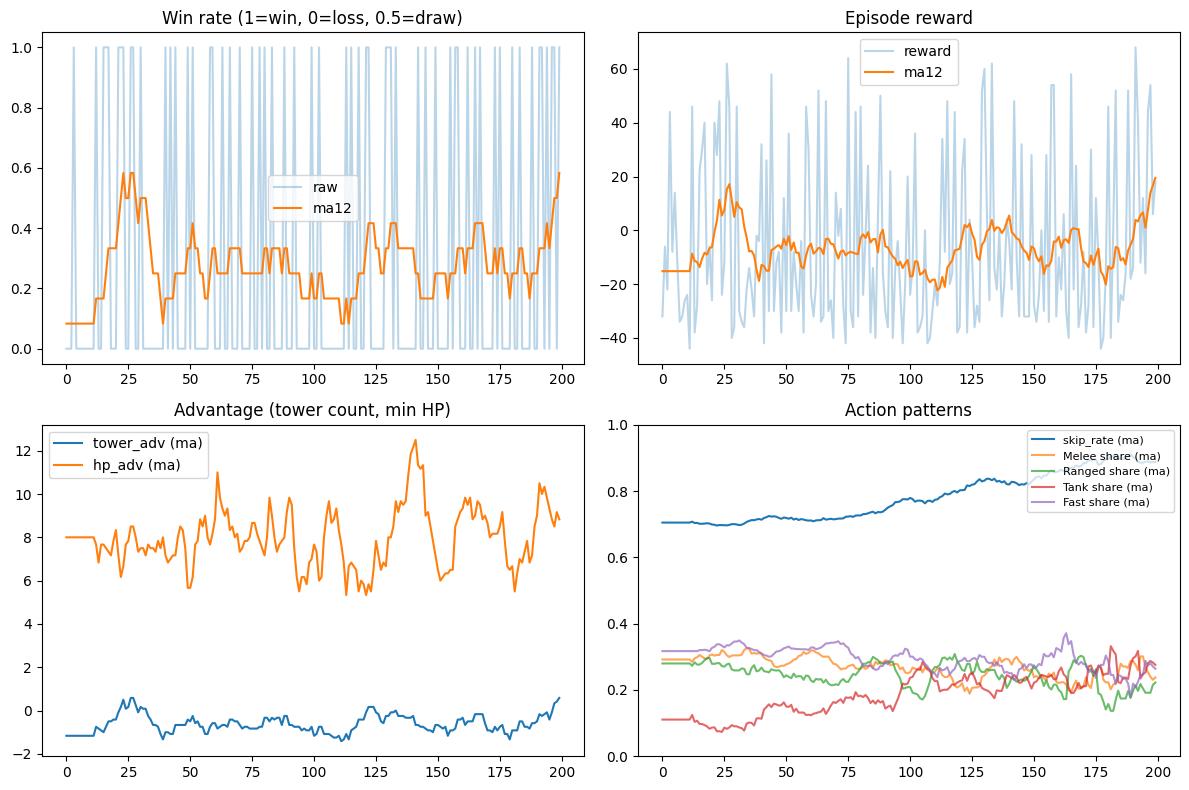

In [20]:
plot_training('research/hrm-agent/runs', window=12)